# Exploratory Data Analysis

This notebook explores the COMPAS dataset to better understand the variables, target outcome, and demographic patterns that will be important for later model auditing.

The goals of this notebook are to:

- Examine the structure of the dataset.
- Explore the target variable, `two_year_recid`.
- Review key demographic and case-related variables.
- Visualize score distributions and recidivism rates.
- Begin identifying fairness-related questions for later analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

In [2]:
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"

df = pd.read_csv(url)

df.head()

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_jail_in,c_jail_out,c_case_number,c_offense_date,c_arrest_date,c_days_from_compas,c_charge_degree,c_charge_desc,is_recid,r_case_number,r_charge_degree,r_days_from_arrest,r_offense_date,r_charge_desc,r_jail_in,r_jail_out,violent_recid,is_violent_recid,vr_case_number,vr_charge_degree,vr_offense_date,vr_charge_desc,type_of_assessment,decile_score.1,score_text,screening_date,v_type_of_assessment,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,0,1,0,0,0,-1.0,2013-08-13 06:03:42,2013-08-14 05:41:20,13011352CF10A,2013-08-13,NaN,1.0,F,Aggravated Assault w/Firearm,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-08-14,Risk of Violence,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,0,3,0,0,0,-1.0,2013-01-26 03:45:27,2013-02-05 05:36:53,13001275CF10A,2013-01-26,NaN,1.0,F,Felony Battery w/Prior Convict,1,13009779CF10A,(F3),NaN,2013-07-05,Felony Battery (Dom Strang),NaN,NaN,NaN,1,13009779CF10A,(F3),2013-07-05,Felony Battery (Dom Strang),Risk of Recidivism,3,Low,2013-01-27,Risk of Violence,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,0,4,0,1,4,-1.0,2013-04-13 04:58:34,2013-04-14 07:02:04,13005330CF10A,2013-04-13,NaN,1.0,F,Possession of Cocaine,1,13011511MM10A,(M1),0.0,2013-06-16,Driving Under The Influence,2013-06-16,2013-06-16,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,4,Low,2013-04-14,Risk of Violence,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,0,8,1,0,1,NaN,NaN,NaN,13000570CF10A,2013-01-12,NaN,1.0,F,Possession of Cannabis,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,8,High,2013-01-13,Risk of Violence,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,0,1,0,0,2,NaN,NaN,NaN,12014130CF10A,NaN,2013-01-09,76.0,F,arrest case no charge,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-03-26,Risk of Violence,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0


In [3]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 7214
Columns: 53


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7214 entries, 0 to 7213
Data columns (total 53 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       7214 non-null   int64  
 1   name                     7214 non-null   object 
 2   first                    7214 non-null   object 
 3   last                     7214 non-null   object 
 4   compas_screening_date    7214 non-null   object 
 5   sex                      7214 non-null   object 
 6   dob                      7214 non-null   object 
 7   age                      7214 non-null   int64  
 8   age_cat                  7214 non-null   object 
 9   race                     7214 non-null   object 
 10  juv_fel_count            7214 non-null   int64  
 11  decile_score             7214 non-null   int64  
 12  juv_misd_count           7214 non-null   int64  
 13  juv_other_count          7214 non-null   int64  
 14  priors_count            

In [5]:
df.describe(include="all").T.head(20)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,7214.0,NaN,NaN,NaN,5501.255753,3175.70687,1.0,2735.25,5509.5,8246.5,11001.0
name,7214,7158,anthony smith,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
first,7214,2800,michael,149,NaN,NaN,NaN,NaN,NaN,NaN,NaN
last,7214,3950,williams,83,NaN,NaN,NaN,NaN,NaN,NaN,NaN
compas_screening_date,7214,690,2013-03-20,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,7214,2,Male,5819,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dob,7214,5452,1994-07-15,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,7214.0,NaN,NaN,NaN,34.817993,11.888922,18.0,25.0,31.0,42.0,96.0
age_cat,7214,3,25 - 45,4109,NaN,NaN,NaN,NaN,NaN,NaN,NaN
race,7214,6,African-American,3696,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
columns_of_interest = [
    "age",
    "age_cat",
    "sex",
    "race",
    "juv_fel_count",
    "juv_misd_count",
    "juv_other_count",
    "priors_count",
    "c_charge_degree",
    "decile_score",
    "score_text",
    "two_year_recid"
]

eda_df = df[columns_of_interest].copy()

eda_df.head()

,age,age_cat,sex,race,juv_fel_count,juv_misd_count,juv_other_count,priors_count,c_charge_degree,decile_score,score_text,two_year_recid
0,69,Greater than 45,Male,Other,0,0,0,0,F,1,Low,0
1,34,25 - 45,Male,African-American,0,0,0,0,F,3,Low,1
2,24,Less than 25,Male,African-American,0,0,1,4,F,4,Low,1
3,23,Less than 25,Male,African-American,0,1,0,1,F,8,High,0
4,43,25 - 45,Male,Other,0,0,0,2,F,1,Low,0


In [7]:
eda_df.isnull().sum().sort_values(ascending=False)

,0
age,0
age_cat,0
sex,0
race,0
juv_fel_count,0
juv_misd_count,0
juv_other_count,0
priors_count,0
c_charge_degree,0
decile_score,0


## Missing Values

This subset of variables has limited missingness, thus I am making the judgment call to use as-is for the initial EDA. Later notebooks will handle preprocessing more formally before model training.

In [8]:
eda_df["two_year_recid"].value_counts()

,count
two_year_recid,
0,3963
1,3251


In [9]:
eda_df["two_year_recid"].value_counts(normalize=True)

,proportion
two_year_recid,
0,0.549348
1,0.450652


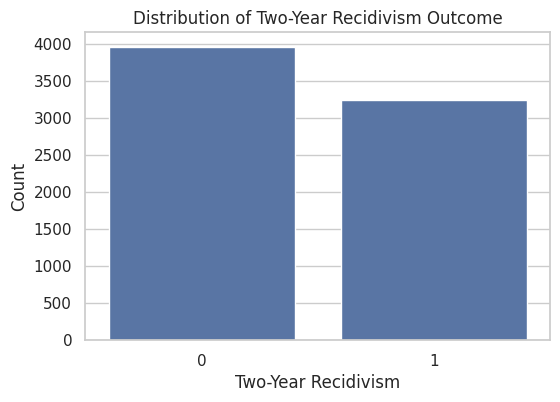

In [10]:
plt.figure(figsize=(6, 4))
sns.countplot(data=eda_df, x="two_year_recid")
plt.title("Distribution of Two-Year Recidivism Outcome")
plt.xlabel("Two-Year Recidivism")
plt.ylabel("Count")
plt.show()

## Target Variable Interpretation

The variable `two_year_recid` indicates whether a person was charged with a new offense within two years. This is  the target variable in the later modeling notebook.

Before building a model, it is important to understand the distribution of the target because class imbalance can affect how model performance should be interpreted.

In [11]:
eda_df["race"].value_counts()

,count
race,
African-American,3696
Caucasian,2454
Hispanic,637
Other,377
Asian,32
Native American,18


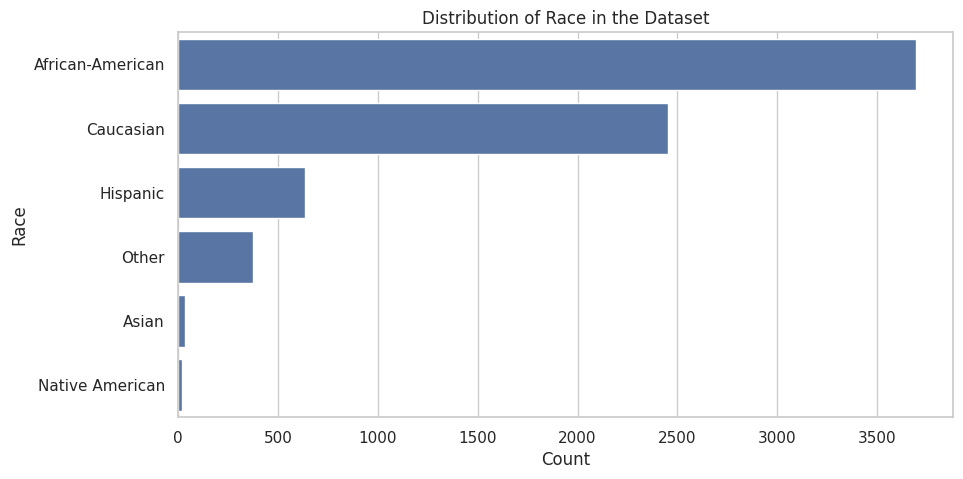

In [12]:
plt.figure(figsize=(10, 5))
sns.countplot(data=eda_df, y="race", order=eda_df["race"].value_counts().index)
plt.title("Distribution of Race in the Dataset")
plt.xlabel("Count")
plt.ylabel("Race")
plt.show()

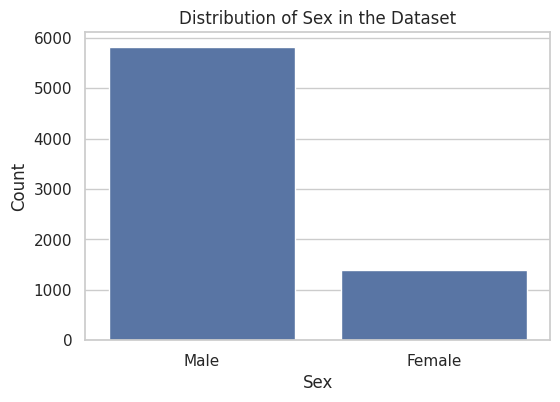

In [13]:
plt.figure(figsize=(6, 4))
sns.countplot(data=eda_df, x="sex")
plt.title("Distribution of Sex in the Dataset")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()

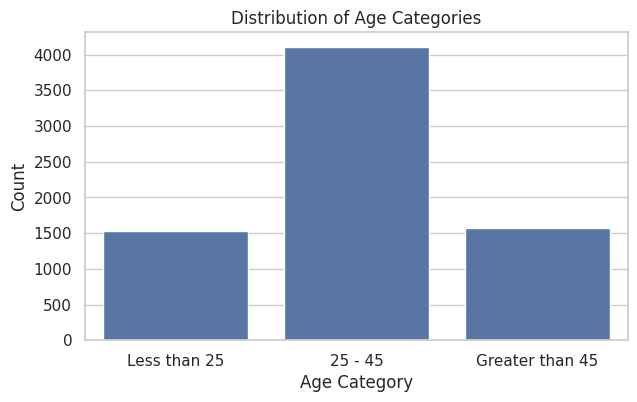

In [14]:
plt.figure(figsize=(7, 4))
sns.countplot(data=eda_df, x="age_cat", order=["Less than 25", "25 - 45", "Greater than 45"])
plt.title("Distribution of Age Categories")
plt.xlabel("Age Category")
plt.ylabel("Count")
plt.show()

## Demographic Variables

The dataset includes demographic variables such as race, sex, and age category. These variables should be handled carefully because they are directly relevant to fairness analysis.

In later notebooks, these variables will be used to compare model performance and error rates across groups.

##Time to Eplore the COMPAS Scores

In [15]:
eda_df["decile_score"].describe()

,decile_score
count,7214.000000
mean,4.509565
std,2.856396
min,1.000000
25%,2.000000
50%,4.000000
75%,7.000000
max,10.000000


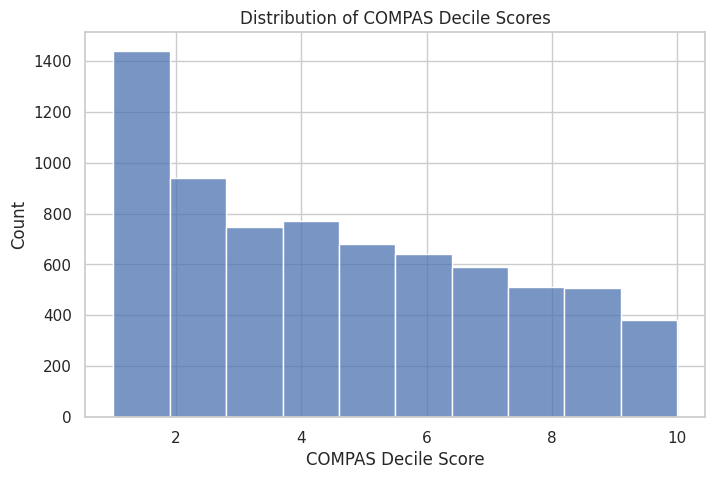

In [16]:
plt.figure(figsize=(8, 5))
sns.histplot(data=eda_df, x="decile_score", bins=10)
plt.title("Distribution of COMPAS Decile Scores")
plt.xlabel("COMPAS Decile Score")
plt.ylabel("Count")
plt.show()

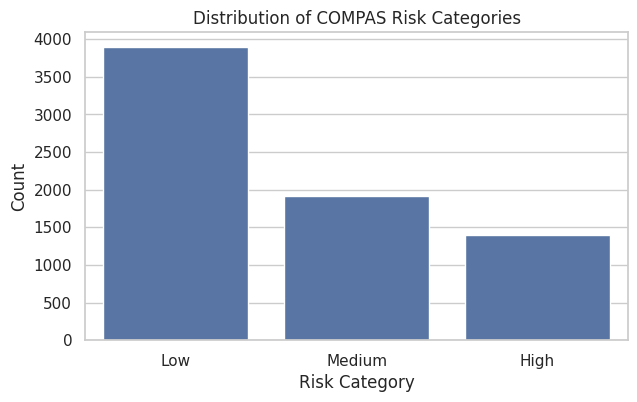

In [17]:
plt.figure(figsize=(7, 4))
sns.countplot(data=eda_df, x="score_text", order=["Low", "Medium", "High"])
plt.title("Distribution of COMPAS Risk Categories")
plt.xlabel("Risk Category")
plt.ylabel("Count")
plt.show()

##Recidivism Rates by Subgroups

In [18]:
recid_by_race = (
    eda_df.groupby("race")["two_year_recid"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

recid_by_race

,race,two_year_recid
0,Native American,0.555556
1,African-American,0.514340
2,Caucasian,0.393643
3,Hispanic,0.364207
4,Other,0.352785
5,Asian,0.281250


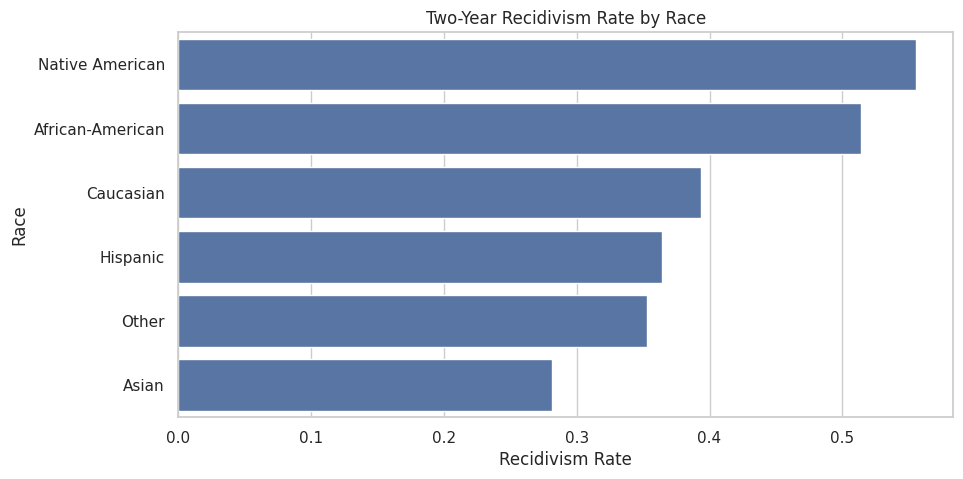

In [19]:
plt.figure(figsize=(10, 5))
sns.barplot(data=recid_by_race, x="two_year_recid", y="race")
plt.title("Two-Year Recidivism Rate by Race")
plt.xlabel("Recidivism Rate")
plt.ylabel("Race")
plt.show()

In [20]:
recid_by_sex = (
    eda_df.groupby("sex")["two_year_recid"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

recid_by_sex

,sex,two_year_recid
0,Male,0.473105
1,Female,0.356989


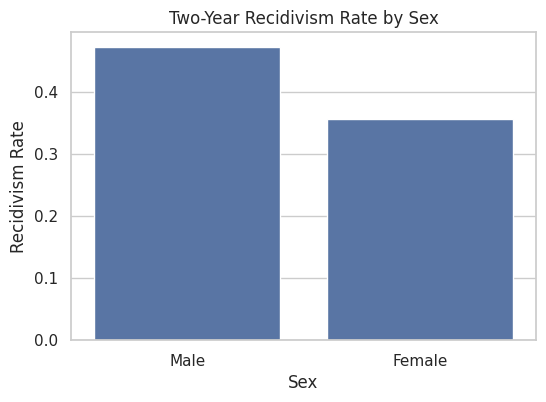

In [21]:
plt.figure(figsize=(6, 4))
sns.barplot(data=recid_by_sex, x="sex", y="two_year_recid")
plt.title("Two-Year Recidivism Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Recidivism Rate")
plt.show()

In [22]:
recid_by_age = (
    eda_df.groupby("age_cat")["two_year_recid"]
    .mean()
    .reindex(["Less than 25", "25 - 45", "Greater than 45"])
    .reset_index()
)

recid_by_age

,age_cat,two_year_recid
0,Less than 25,0.565075
1,25 - 45,0.459723
2,Greater than 45,0.315990


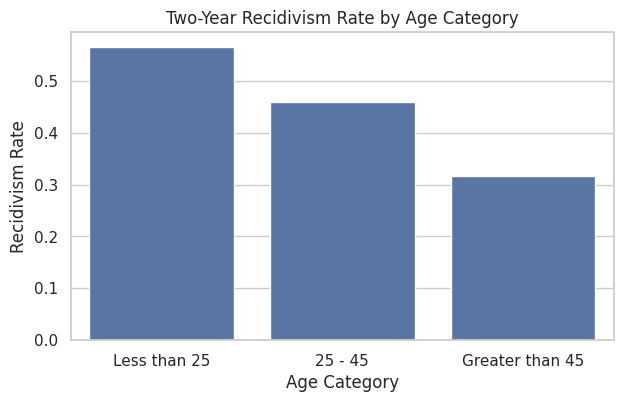

In [23]:
plt.figure(figsize=(7, 4))
sns.barplot(data=recid_by_age, x="age_cat", y="two_year_recid")
plt.title("Two-Year Recidivism Rate by Age Category")
plt.xlabel("Age Category")
plt.ylabel("Recidivism Rate")
plt.show()

##COMPAS Score By Race

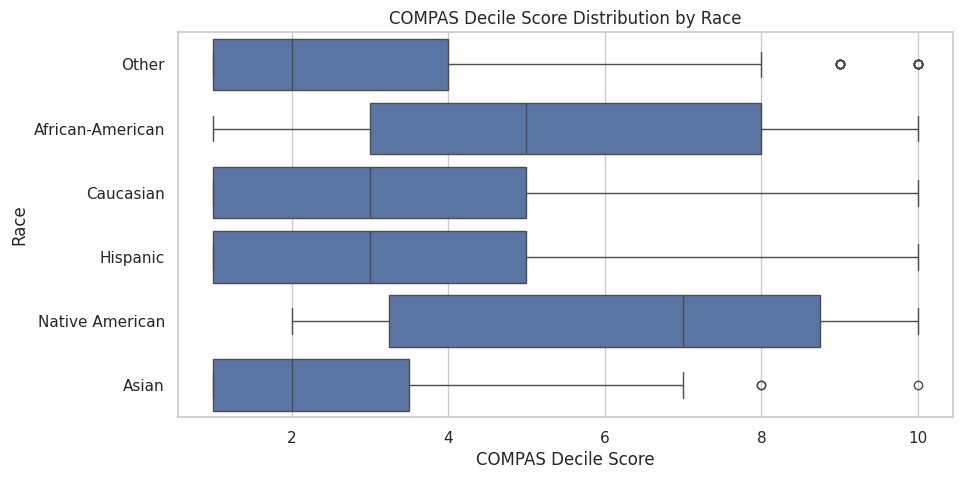

In [24]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=eda_df, x="decile_score", y="race")
plt.title("COMPAS Decile Score Distribution by Race")
plt.xlabel("COMPAS Decile Score")
plt.ylabel("Race")
plt.show()

##Crosstab of Risk Category and Outcome

In [25]:
pd.crosstab(
    eda_df["score_text"],
    eda_df["two_year_recid"],
    normalize="index"
)

two_year_recid,0,1
score_text,,
High,0.286529,0.713471
Low,0.687965,0.312035
Medium,0.459770,0.540230


## Initial Fairness Questions

This exploratory analysis raises several questions for later model auditing:

1. Do predictive error rates differ across demographic groups?
2. Are false positive rates higher for some groups than others?
3. Are false negative rates higher for some groups than others?
4. Does aggregate model accuracy hide subgroup-level harms?
5. Which features appear to drive model predictions?

These questions will guide the fairness evaluation and explainability notebooks.